# Experiment 1 – Label Probability Calibration

Analyses **token-level uncertainty** in multiple-choice QA: how well the
label-choice probabilities assigned by a model reflect its actual likelihood of
being correct.

Pipeline:
1. Load raw benchmark results (one CSV per prompt × dataset × model) and compute
   calibration metrics in a single memory-efficient loop.
2. Delete each raw DataFrame immediately after metric computation to minimise peak
   RAM usage.
3. Visualise calibration grids (binned and relplot variants), the normalisation
   effect, label-choice bias, and generate LaTeX tables.

For each `(prompt, dataset, model)` cell, four calibration objects are produced
(normalize × chosen_only):

* `"norm_chosen"` – L1-normalised probabilities, argmax label only
* `"norm_all"`    – L1-normalised probabilities, all 4 labels
* `"raw_chosen"`  – raw token probabilities, argmax label only
* `"raw_all"`     – raw token probabilities, all 4 labels

Each leaf dict also contains a `"relplot_diagram"` key for smooth-ECE reliability
diagrams.

In [1]:
%load_ext autoreload
%autoreload 2

## Imports

In [2]:
import os
import re
import statistics
from collections import defaultdict
from itertools import product

import matplotlib as mpl
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import relplot as rp
from async_graph_bench import CSVDataStore
from matplotlib.collections import PatchCollection
from matplotlib.colors import to_rgb

In [3]:
# Config: models, all_datasets, datasets_by_id, prompt_designs, prompt_basenames, paths, safe_format
from analysis_config import (
    models,
    all_datasets,
    datasets_by_id,
    prompt_designs,
    prompt_basenames,
    FIGURES_DIR,
    TABLES_DIR,
    COMPUTE_RELPLOT_FOR_ALL_VARIANTS,
    safe_format,
)

# compute_all_variants: parse each label-prob DataFrame once and return all four
# (normalize × chosen_only) calibration metrics dicts from shared numpy arrays.
# Also returns raw (correct, certainties) arrays per variant for relplot.
from analysis_utils.calibration_compute import compute_all_variants

# Calibration grid builders, subplot helpers, relplot subplot, normalization comparison
from analysis_utils.calibration_plot_helpers import (
    _cal_key,
    make_calibration_subplot_fn,
    plot_relplot_subplot,
    render_metrics_table,
    build_calibration_grid,
    save_all_calibration_grids,
    plot_normalization_comparison,
)

# Global matplotlib style defaults (font family, figure background, etc.)
from util.config import apply_matplotlib_defaults

## Setup

In [4]:
apply_matplotlib_defaults()

for d in [FIGURES_DIR, TABLES_DIR, FIGURES_DIR / "full_plots"]:
    os.makedirs(d, exist_ok=True)

## Data Loading and Metric Computation

Data loading and calibration computation in one memory-efficient loop.  For every
`(prompt, dataset, model)` triplet:

* Load the raw CSV into a DataFrame.
* Compute calibration metrics for all 4 `normalize × chosen_only` combinations.
  `return_arrays=True` yields the raw `(correct, certainties)` arrays so that the
  relplot diagram can be computed inline before the arrays are discarded.
* Accumulate label-bias probability mass per model (first prompt only).
* `del df` immediately to free memory.

`cal_data[pname][ds_id][m_id]` → dict with keys `"norm_chosen"`, `"norm_all"`,
`"raw_chosen"`, `"raw_all"` (or `None` when the CSV was missing).

In [5]:
def load_label_prob_df(prompt, dataset, model):
    """Load the raw label-probability CSV for one (prompt, dataset, model) triplet.

    Uses ``dataset['data_path_id']`` (if present) as the on-disk subdirectory name
    so MMLU_Physics results are read from the MMLU benchmark directory rather than
    a non-existent MMLU_Physics one.

    Args:
        prompt:  Prompt design dict with a ``path`` key.
        dataset: Dataset dict from the experiment-1 registry.
        model:   Model dict with an ``id`` key.

    Returns:
        pd.DataFrame or None: Raw model output, or None if the file is missing.
    """
    disk_id = dataset.get("data_path_id", dataset["id"])
    result_path = prompt["path"] / disk_id / model["id"]
    try:
        return CSVDataStore(result_path, "LabelProbExtractor").to_dataframe()
    except Exception as e:
        print(f"  [load] missing: {result_path} – {e}")
        return None

In [6]:
# cal_data[pname][ds_id][m_id] → dict of 4 calibration dicts (or None if CSV missing).
cal_data = {
    pname: {ds["id"]: {} for ds in all_datasets}
    for pname in prompt_basenames
}

# Label bias: normalised probability mass accumulated per label index per model.
# Only the first prompt design is used (consistent with the original analysis).
labels_chosen_count  = defaultdict(lambda: defaultdict(float))
_label_bias_prompt   = prompt_designs[0]

# Ground-truth correct-answer distribution (reference for label-bias comparison).
actual_correct_label_count = defaultdict(int)
for dataset in all_datasets:
    for label, count in dataset["df"]["correct_answer"].value_counts().items():
        actual_correct_label_count[label] += count

for prompt, dataset, model in product(prompt_designs, all_datasets, models):
    pname, ds_id, m_id = prompt["basename"], dataset["id"], model["id"]
    print(f"Loading  {pname}/{ds_id}/{m_id}")
    df = load_label_prob_df(prompt, dataset, model)

    if df is None:
        cal_data[pname][ds_id][m_id] = None
        continue

    # Parse the DataFrame once; derive all 4 (normalize × chosen_only) variants
    # from shared numpy arrays — ~4× faster than calling compute_calibration_metrics
    # four times separately.
    try:
        metrics_dict, arrays_dict = compute_all_variants(dataset["df"], df, n_bins=15)
    except Exception as e:
        print(f"  ERROR compute_all_variants: {e}")
        cal_data[pname][ds_id][m_id] = None
        del df
        continue

    entry = {}
    for key, metrics in metrics_dict.items():
        chosen_only = key.endswith("_chosen")
        # Compute relplot diagram.  For "all" variants this can be skipped during
        # development by setting COMPUTE_RELPLOT_FOR_ALL_VARIANTS = False in
        # analysis_config.py to roughly halve bootstrap-CI computation cost.
        should_compute_relplot = chosen_only or COMPUTE_RELPLOT_FOR_ALL_VARIANTS
        correct_arr, certainties_arr = arrays_dict[key]
        if should_compute_relplot and len(correct_arr) > 0:
            try:
                metrics["relplot_diagram"] = rp.prepare_rel_diagram(
                    f=certainties_arr.astype(float),
                    y=correct_arr.astype(float),
                    plot_confidence_band=False, #TODO
                    report_CE_std=False,
                    kde_bandwidth=0.02
                )
            except Exception as e:
                print(f"  relplot ERROR {key}: {e}")
                metrics["relplot_diagram"] = None
        else:
            metrics["relplot_diagram"] = None
        entry[key] = metrics

    # Accumulate normalised probability mass per label index (first prompt only).
    # Uses vectorised numpy ops to avoid iterrows() overhead.
    if prompt is _label_bias_prompt:
        probs_mat = np.stack(
            df["confidence_per_choice"].apply(lambda x: np.asarray(x, dtype=float)).values
        )  # (N, 4)
        row_sums = probs_mat.sum(axis=1, keepdims=True)
        probs_norm = np.where(row_sums > 0, probs_mat / row_sums, 0.25)
        for i, v in enumerate(probs_norm.sum(axis=0)):
            labels_chosen_count[m_id][i] += float(v)

    cal_data[pname][ds_id][m_id] = entry
    del df  # free memory immediately after computation

Loading  data_prompt_1/MMLU/gpt-oss-20b


C:\Users\PHMU3\Google Drive Dev\llm-uncertainty-bench-repo\llm-uncertainty-bench\label_prob_calibration\analysis_utils\calibration_compute.py:380: RuntimeWarning: invalid value encountered in divide
  norm_mat = np.where(row_sums > 0, raw_mat / row_sums, 0.0)  # (N, 4)
C:\Users\PHMU3\AppData\Local\Temp\ipykernel_8796\941163704.py:69: RuntimeWarning: invalid value encountered in divide
  probs_norm = np.where(row_sums > 0, probs_mat / row_sums, 0.25)


Loading  data_prompt_1/MMLU/gpt-oss-120b
Loading  data_prompt_1/MMLU/Ministral-8B-Instruct-2410
Loading  data_prompt_1/MMLU/Mistral-Nemo-Base-2407
Loading  data_prompt_1/MMLU/Mistral-Nemo-Instruct-2407
Loading  data_prompt_1/MMLU/Mistral-Small-3.1-24B-Base-2503
Loading  data_prompt_1/MMLU/Mistral-Small-3.2-24B-Instruct-2506
Loading  data_prompt_1/MMLU/Magistral-Small-2507
Loading  data_prompt_1/MMLU/Magistral-Small-2507
Loading  data_prompt_1/MMLU/Llama-3.1-70B
Loading  data_prompt_1/MMLU/Llama-3.3-70B-Instruct
Loading  data_prompt_1/MMLU/Llama-4-Scout-17B-16E
Loading  data_prompt_1/MMLU/Llama-4-Scout-17B-16E-Instruct
Loading  data_prompt_1/MMLU/Qwen3-30B-A3B-Base
Loading  data_prompt_1/MMLU/Qwen3-30B-A3B-Instruct-2507
Loading  data_prompt_1/MMLU/Qwen3-30B-A3B-Thinking-2507


C:\Users\PHMU3\Google Drive Dev\llm-uncertainty-bench-repo\llm-uncertainty-bench\label_prob_calibration\analysis_utils\calibration_compute.py:380: RuntimeWarning: invalid value encountered in divide
  norm_mat = np.where(row_sums > 0, raw_mat / row_sums, 0.0)  # (N, 4)
C:\Users\PHMU3\AppData\Local\Temp\ipykernel_8796\941163704.py:69: RuntimeWarning: invalid value encountered in divide
  probs_norm = np.where(row_sums > 0, probs_mat / row_sums, 0.25)


Loading  data_prompt_1/MMLU/DeepSeek-R1-Distill-Llama-70B


...

Loading  data_prompt_1/GPQA/Mistral-Nemo-Base-2407
Loading  data_prompt_1/GPQA/Mistral-Nemo-Instruct-2407
Loading  data_prompt_1/GPQA/Mistral-Small-3.1-24B-Base-2503
Loading  data_prompt_1/GPQA/Mistral-Small-3.2-24B-Instruct-2506
Loading  data_prompt_1/GPQA/Magistral-Small-2507
Loading  data_prompt_1/GPQA/Magistral-Small-2507
Loading  data_prompt_1/GPQA/Llama-3.1-70B
Loading  data_prompt_1/GPQA/Llama-3.3-70B-Instruct
Loading  data_prompt_1/GPQA/Llama-4-Scout-17B-16E
Loading  data_prompt_1/GPQA/Llama-4-Scout-17B-16E-Instruct
Loading  data_prompt_1/GPQA/Qwen3-30B-A3B-Base
Loading  data_prompt_1/GPQA/Qwen3-30B-A3B-Instruct-2507
Loading  data_prompt_1/GPQA/Qwen3-30B-A3B-Thinking-2507


C:\Users\PHMU3\Google Drive Dev\llm-uncertainty-bench-repo\llm-uncertainty-bench\label_prob_calibration\analysis_utils\calibration_compute.py:380: RuntimeWarning: invalid value encountered in divide
  norm_mat = np.where(row_sums > 0, raw_mat / row_sums, 0.0)  # (N, 4)
C:\Users\PHMU3\AppData\Local\Temp\ipykernel_8796\941163704.py:69: RuntimeWarning: invalid value encountered in divide
  probs_norm = np.where(row_sums > 0, probs_mat / row_sums, 0.25)
C:\Users\PHMU3\Google Drive Dev\llm-uncertainty-bench-repo\llm-uncertainty-bench\label_prob_calibration\analysis_utils\calibration_compute.py:380: RuntimeWarning: invalid value encountered in divide
  norm_mat = np.where(row_sums > 0, raw_mat / row_sums, 0.0)  # (N, 4)


Loading  data_prompt_1/GPQA/DeepSeek-R1-Distill-Llama-70B
Loading  data_prompt_1/GPQA/DeepSeek-R1-Distill-Qwen-32B


C:\Users\PHMU3\AppData\Local\Temp\ipykernel_8796\941163704.py:69: RuntimeWarning: invalid value encountered in divide
  probs_norm = np.where(row_sums > 0, probs_mat / row_sums, 0.25)
C:\Users\PHMU3\Google Drive Dev\llm-uncertainty-bench-repo\llm-uncertainty-bench\label_prob_calibration\analysis_utils\calibration_compute.py:380: RuntimeWarning: invalid value encountered in divide
  norm_mat = np.where(row_sums > 0, raw_mat / row_sums, 0.0)  # (N, 4)
C:\Users\PHMU3\AppData\Local\Temp\ipykernel_8796\941163704.py:69: RuntimeWarning: invalid value encountered in divide
  probs_norm = np.where(row_sums > 0, probs_mat / row_sums, 0.25)


Loading  data_prompt_1/GPQA/gemma-3-27b-pt
Loading  data_prompt_1/GPQA/gemma-3-27b-it


In [7]:
# Normalise accumulated label-bias counts to proportions (must sum to 1 per model).
labels_chosen_proportion = {}
for m_id, counts in labels_chosen_count.items():
    total = sum(counts.values())
    labels_chosen_proportion[m_id] = {label: counts[label] / total for label in range(4)}

total_gt = sum(actual_correct_label_count.values())
actual_correct_label_proportion = {
    i: actual_correct_label_count[i] / total_gt for i in range(4)
}
print("Ground-truth label distribution:", actual_correct_label_proportion)

Ground-truth label distribution: {0: 0.23577739885289103, 1: 0.2505037978607968, 2: 0.2510463494031933, 3: 0.2626724538831189}


## Full Calibration Grids

Generate and save calibration grid SVGs for all combinations of prompt ×
normalisation × label selection.  Both binned-calibration and relplot variants
are saved.

In [8]:
#save_all_calibration_grids(prompt_designs, all_datasets, models, cal_data, FIGURES_DIR)
#apply_matplotlib_defaults()

## Paper Header Plot

A focused calibration grid used as the paper header figure, showing three
representative datasets and four key models with ECE annotations.

C:\Users\PHMU3\AppData\Local\Temp\ipykernel_8796\1135337232.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot.show()


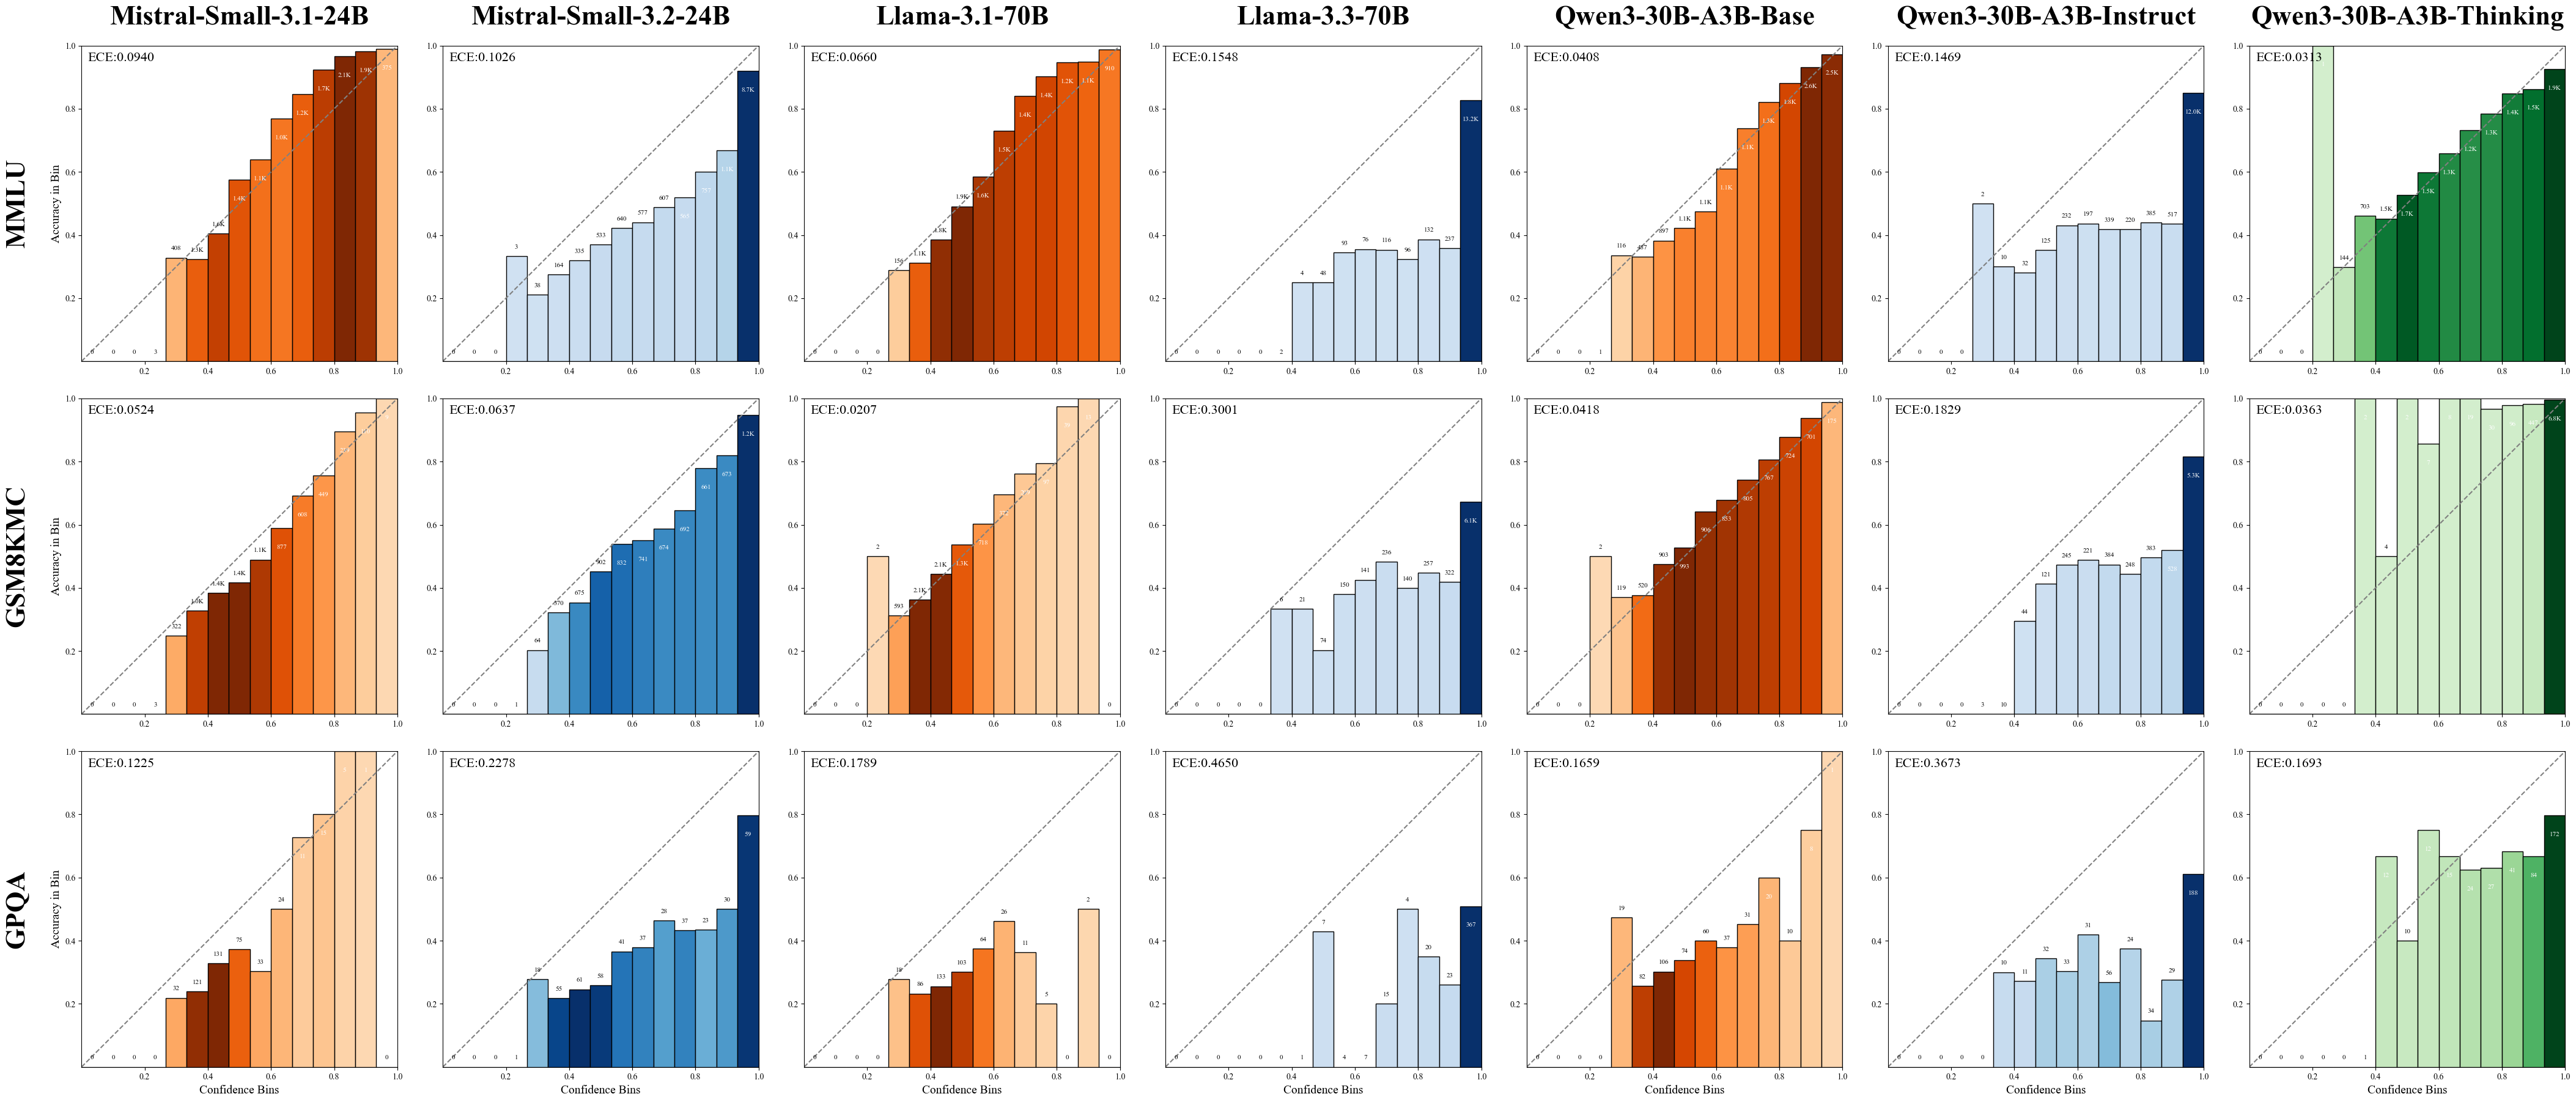

In [9]:
apply_matplotlib_defaults()
plot = build_calibration_grid(
    prompt_designs[0],
    datasets=[d for d in all_datasets if d["id"] in ["MMLU", "GSM8KMC", "GPQA"]],
    models=[m for m in models if any(name in m["basename"] for name in
                                     ["Mistral-Small-3", "Magistral-Small-2507-Reasoning-Enabled",
                                      "Llama-3", "Qwen3-30B-A3B"])],
    cal_data=cal_data,
    chosen_only=True, normalize=True,
    with_table=False, with_title=False,
    ece_in_plot=True,
    row_col_titles_font_size=32,
)
plot.savefig(FIGURES_DIR / "prompt_1_header_plot.svg", bbox_inches="tight")
plot.show()

C:\Users\PHMU3\AppData\Local\Temp\ipykernel_8796\103657347.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  rp_plot.show()


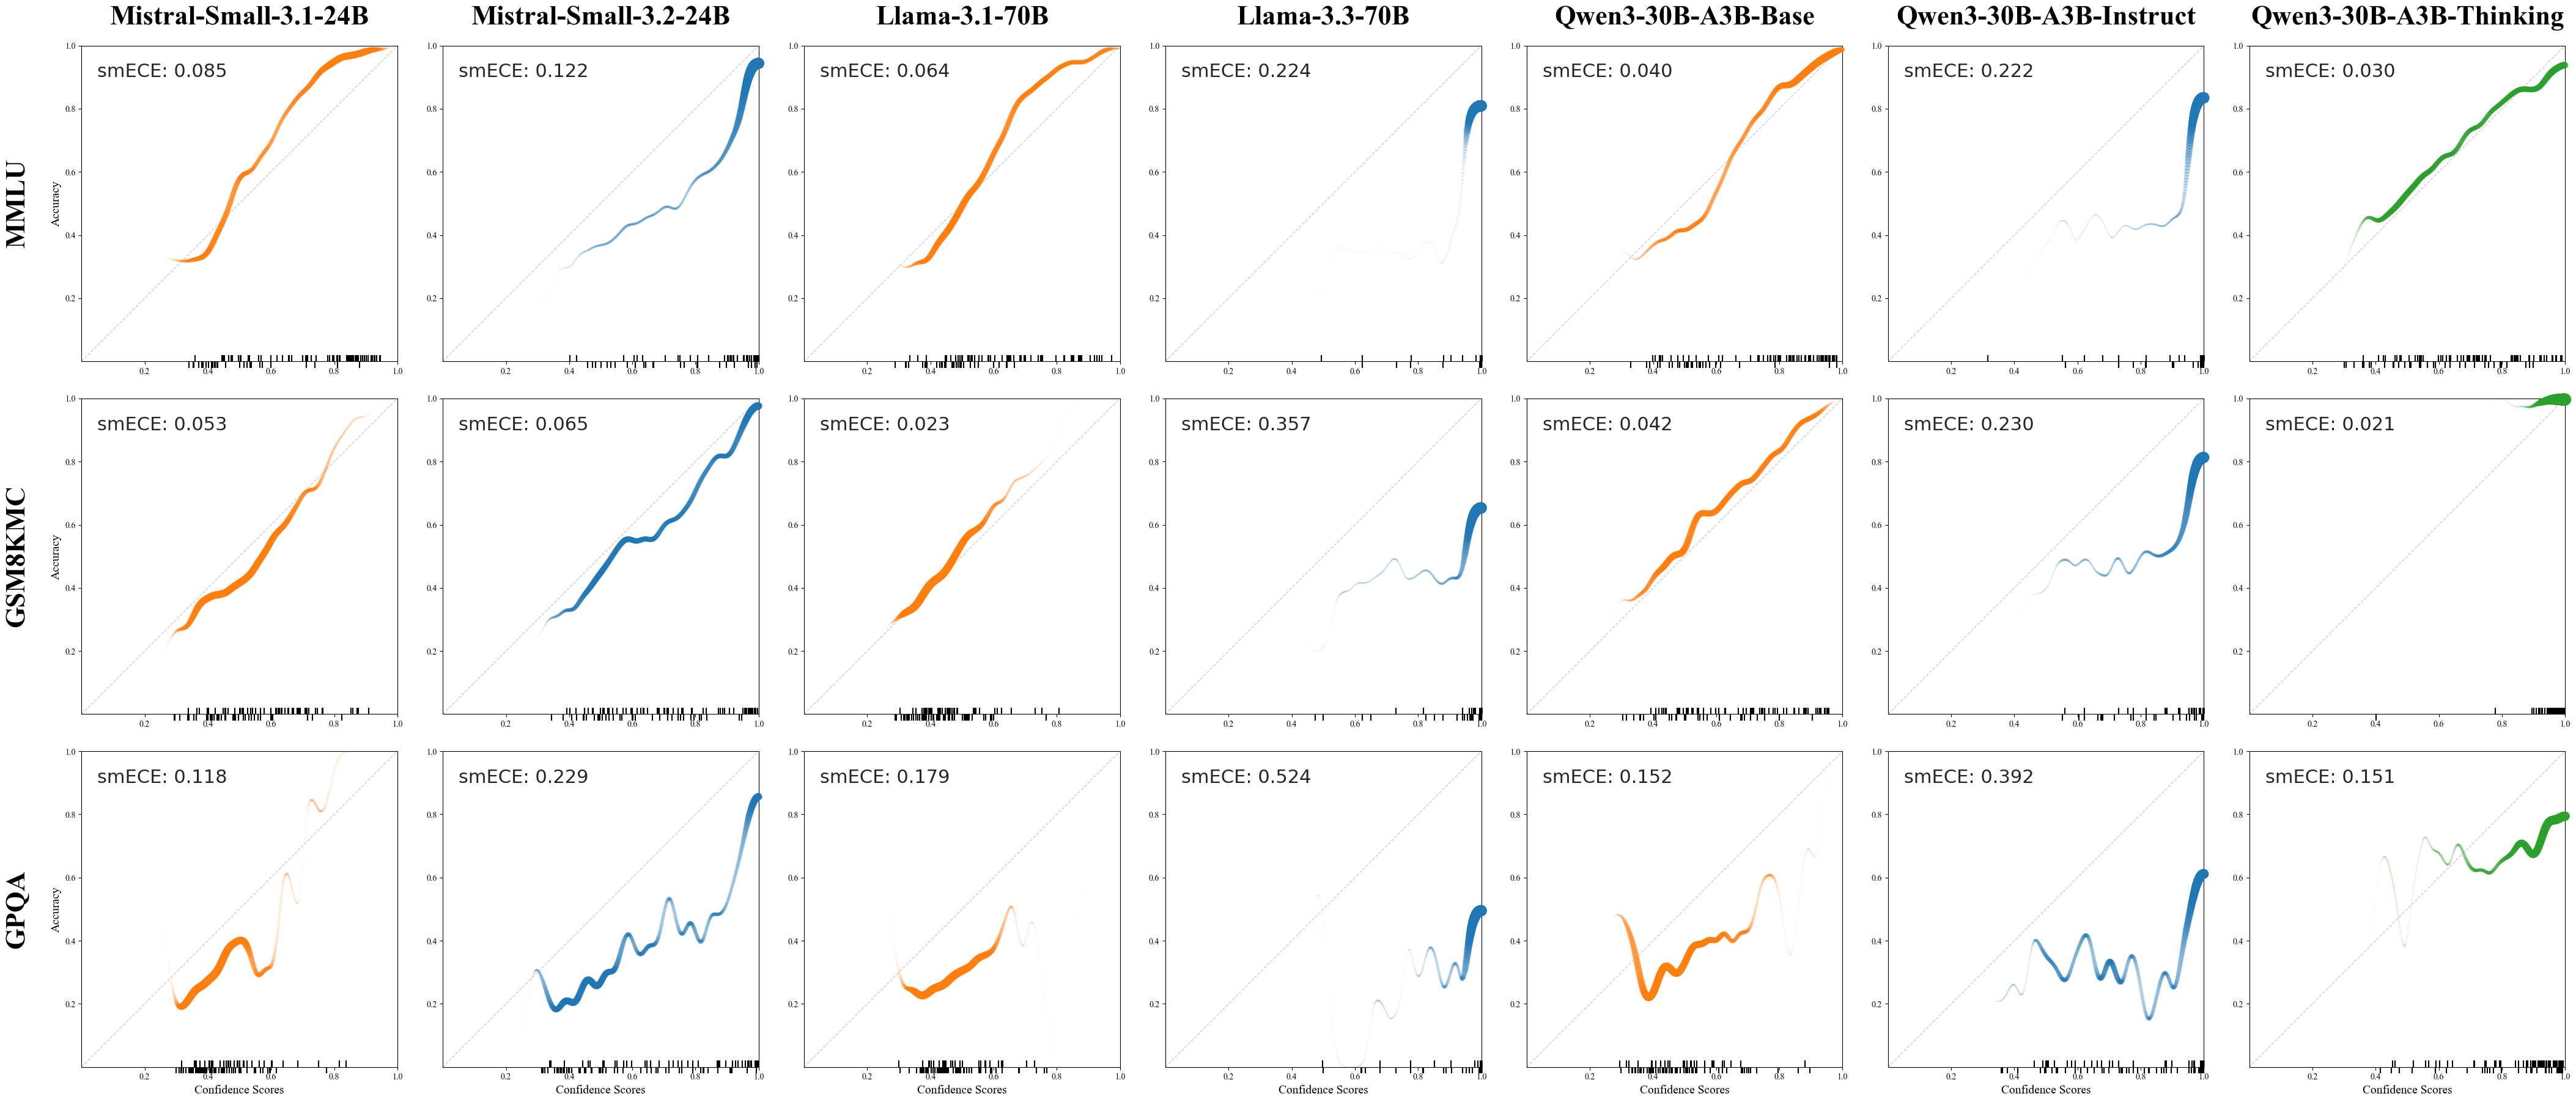

In [10]:
# Relplot (smooth reliability diagram) variant of the paper header figure.
apply_matplotlib_defaults()
rp_plot = build_calibration_grid(
    prompt_designs[0],
    datasets=[d for d in all_datasets if d["id"] in ["MMLU", "GSM8KMC", "GPQA"]],
    models=[m for m in models if any(name in m["basename"] for name in
                                     ["Mistral-Small-3", "Magistral-Small-2507-Reasoning-Enabled",
                                      "Llama-3", "Qwen3-30B-A3B"])],
    cal_data=cal_data,
    chosen_only=True, normalize=True,
    with_table=False, with_title=False,
    subplot_fn=plot_relplot_subplot,
    row_col_titles_font_size=32,
)
rp_plot.savefig(FIGURES_DIR / "prompt_1_header_plot_relplot.svg", bbox_inches="tight")
rp_plot.show()

## Normalization Effect

Side-by-side calibration grids for one model showing the effect of applying
L1-normalisation to the raw token probabilities.

C:\Users\PHMU3\Google Drive Dev\llm-uncertainty-bench-repo\llm-uncertainty-bench\label_prob_calibration\analysis_utils\calibration_plot_helpers.py:347: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot.show()


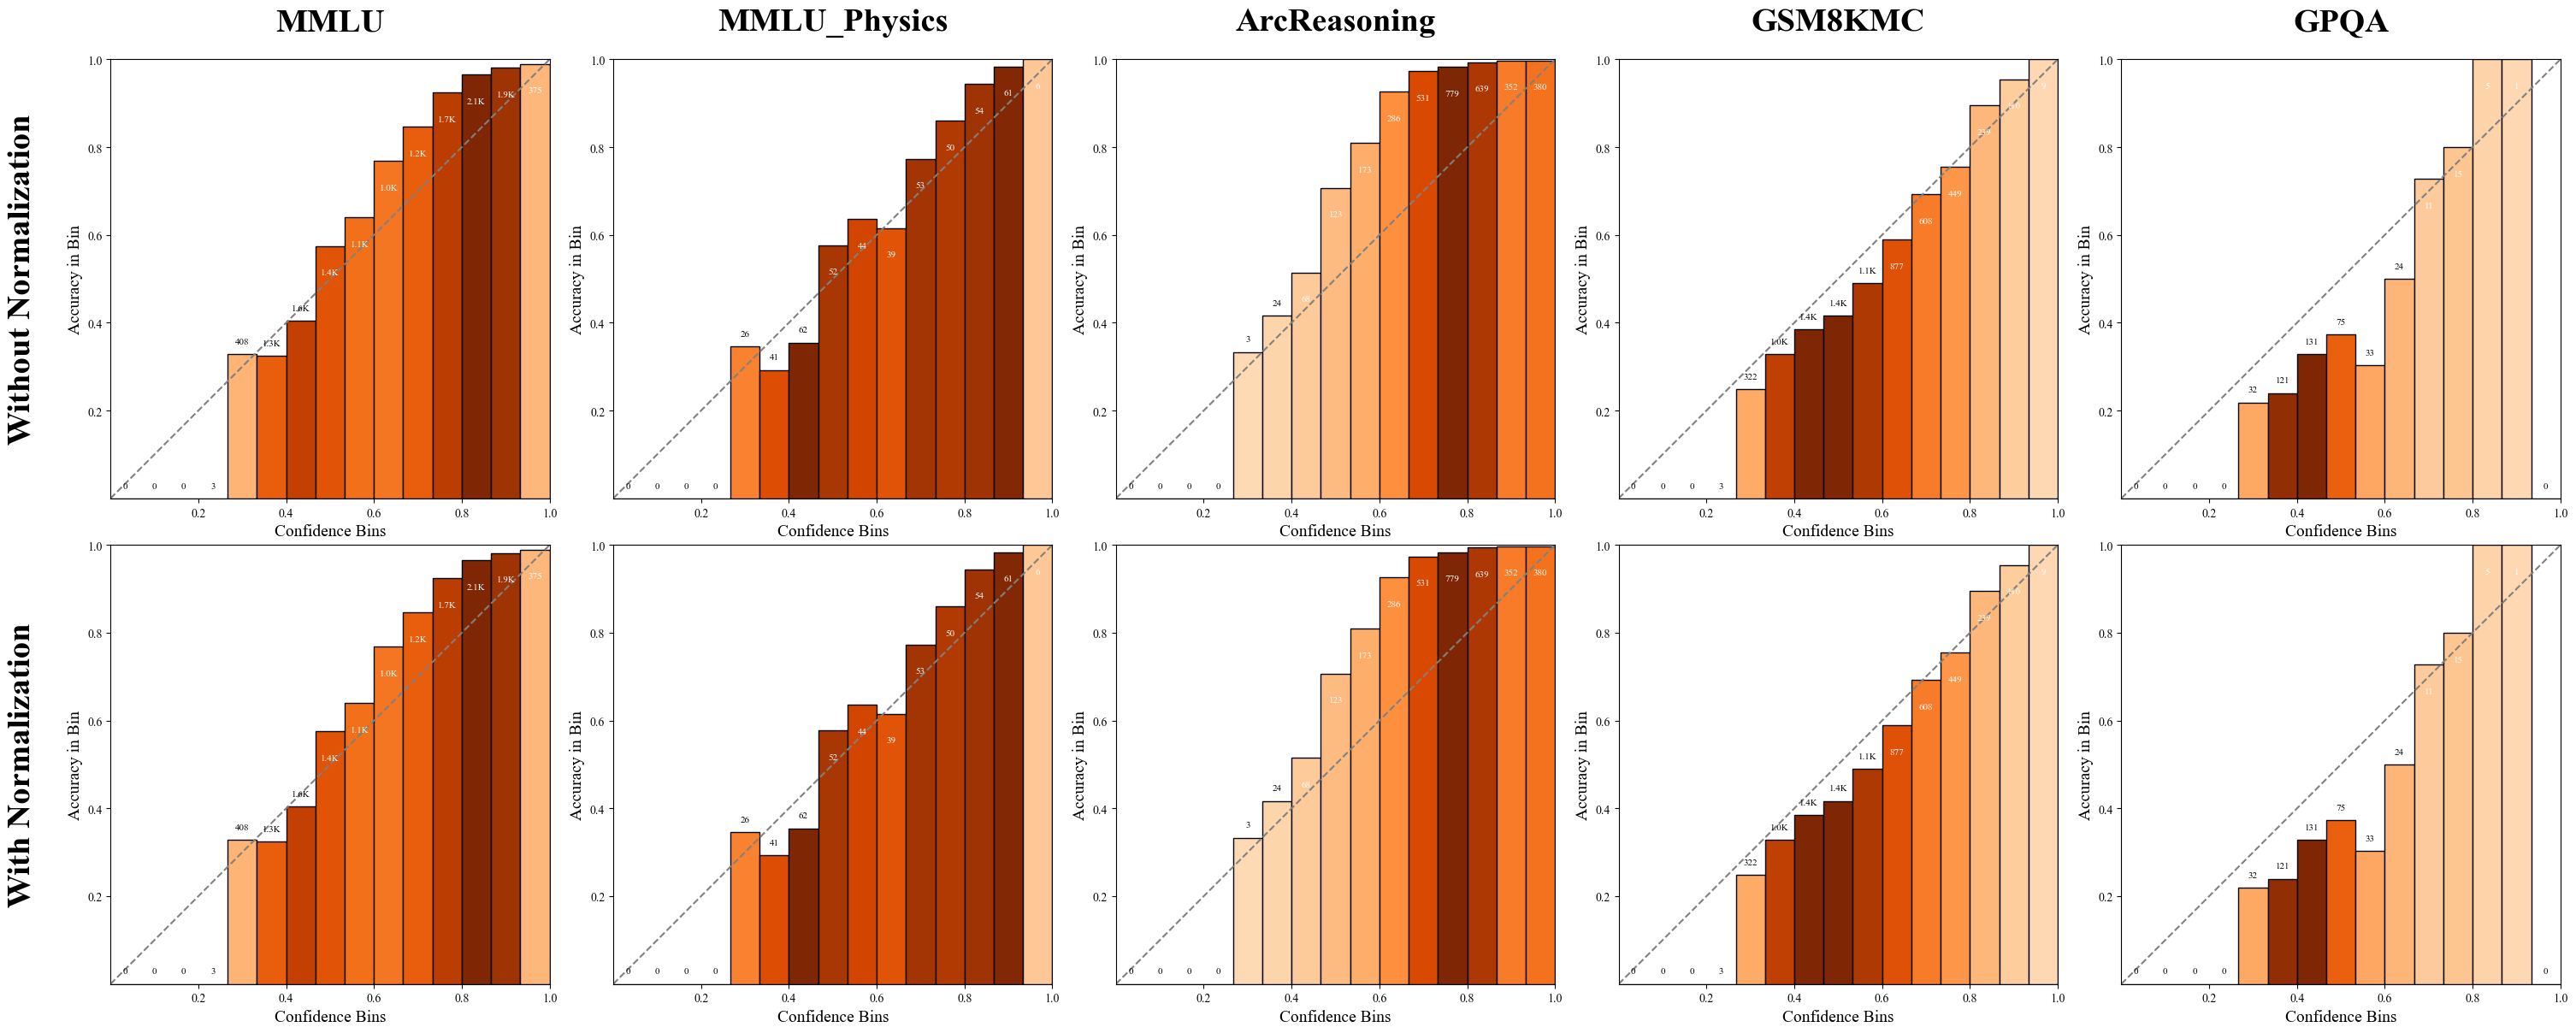

In [11]:
apply_matplotlib_defaults()
plot_normalization_comparison(
    next(m for m in models if "Mistral-Small-3.1-24B-Base-2503" in m["id"]),
    all_datasets,
    prompt_designs[0],
    cal_data=cal_data,
    figures_dir=FIGURES_DIR,
)

## Label Bias Analysis

Visualise how much probability mass each model assigns to each answer-choice
position (A/B/C/D) versus the ground-truth correct-answer distribution.
The x-axis groups bars by label position (A–D); each model gets one bar per
position, coloured by model type (Blues = instruct, Oranges = base,
Greens = reasoning).  A local dashed reference line marks the ground-truth
proportion for each label.

C:\Users\PHMU3\AppData\Local\Temp\ipykernel_8796\595732288.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name)
C:\Users\PHMU3\AppData\Local\Temp\ipykernel_8796\595732288.py:60: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  handles = [plt.Rectangle((0, 0), 1, 1, color=ground_truth_color, edgecolor="black")]
C:\Users\PHMU3\AppData\Local\Temp\ipykernel_8796\595732288.py:61: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  handles += [plt.Rectangle((0, 0), 1, 1, color=model_colors.get(m, "grey"), edgecolor="black")


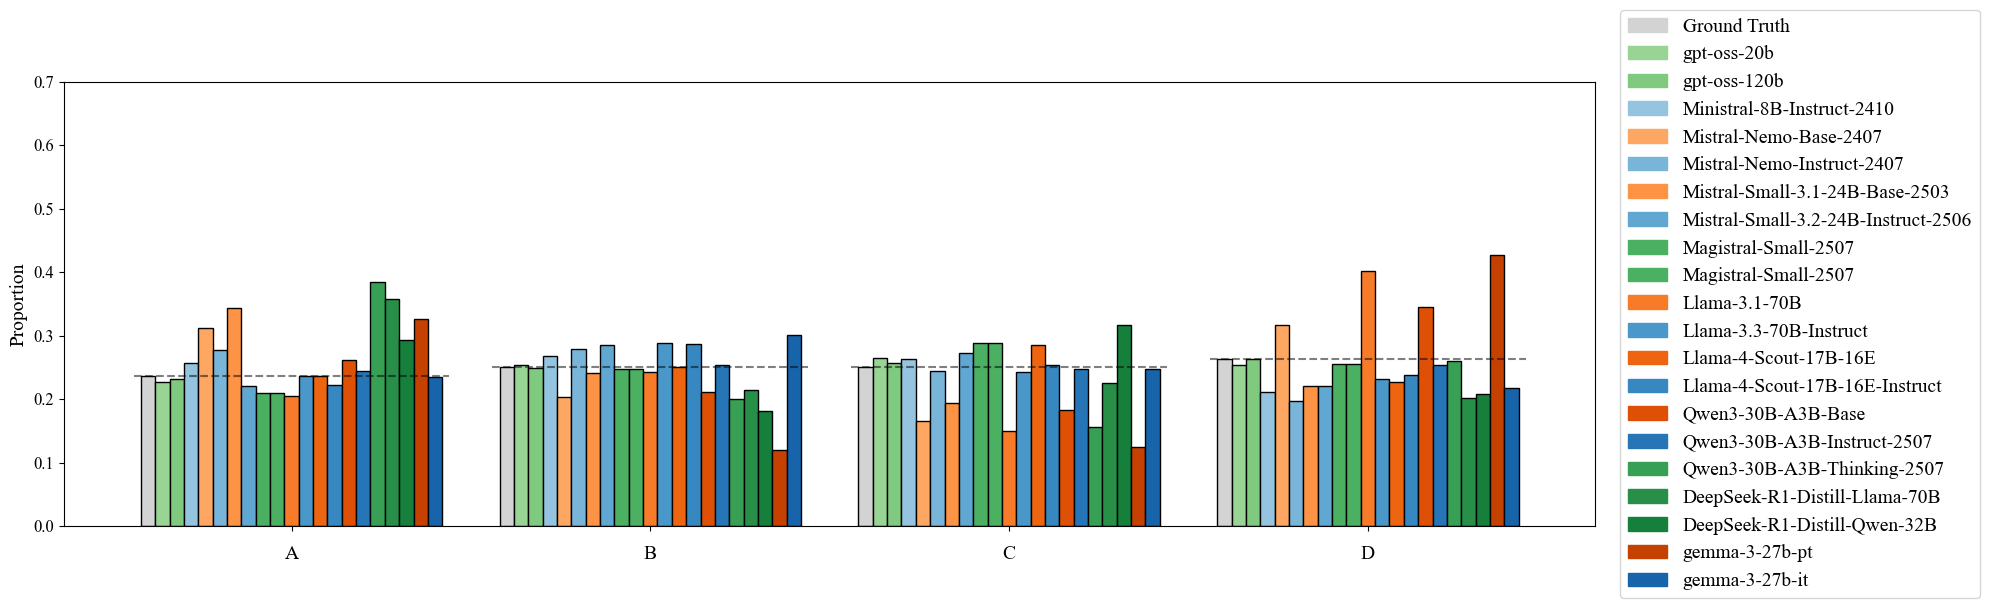

In [12]:
apply_matplotlib_defaults()

labels = ["A", "B", "C", "D"]
num_labels = len(labels)
model_ids = [m["id"] for m in models]

ground_truth = [actual_correct_label_proportion.get(i, 0.0) for i in range(num_labels)]
model_distributions = {
    m_id: [labels_chosen_proportion.get(m_id, {}).get(i, 0.0) for i in range(num_labels)]
    for m_id in model_ids
}

# Assign colours per model: Blues for instruct, Oranges for base, Greens for reasoning.
categories = {
    "instruct": ("Blues",    [m["id"] for m in models if m["type"] == "instruct"]),
    "base":     ("Oranges",  [m["id"] for m in models if m["type"] == "base"]),
    "reasoning":("Greens",   [m["id"] for m in models if m["type"] == "reasoning"]),
}
model_colors = {}
for cmap_name, ids in categories.values():
    cmap = plt.cm.get_cmap(cmap_name)
    colors = cmap(np.linspace(0.4, 0.8, max(len(ids), 1)))
    model_colors.update({m_id: colors[i] for i, m_id in enumerate(ids)})
ground_truth_color = "lightgrey"

bar_width = 0.04
x = np.arange(num_labels)

fig, ax = plt.subplots(figsize=(20, 6))

# Ground-truth bars (leftmost in each group)
ax.bar(
    x - bar_width * (len(models) / 2),
    ground_truth, bar_width,
    label="Ground Truth", color=ground_truth_color, edgecolor="black",
)
# Per-model bars
for i, m_id in enumerate(model_ids):
    ax.bar(
        x - bar_width * (len(model_ids) / 2) + (i + 1) * bar_width,
        model_distributions[m_id], bar_width,
        label=m_id, color=model_colors.get(m_id, "grey"), edgecolor="black",
    )
# Local dashed reference lines (one per label position)
for j, gt in enumerate(ground_truth):
    ax.hlines(
        y=gt,
        xmin=x[j] - bar_width * (len(model_ids) / 2 + 1),
        xmax=x[j] + bar_width * (len(model_ids) / 2 + 1),
        colors="black", linestyles="dashed", alpha=0.5,
    )

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=14)
ax.tick_params(axis="x", pad=10)
ax.set_yticks(np.arange(0.0, 0.8, 0.1))
ax.set_yticklabels([round(v, 1) for v in np.arange(0.0, 0.8, 0.1)], fontsize=12)
ax.set_ylabel("Proportion", fontsize=14)
ax.set_ylim(0, 0.7)
handles = [plt.Rectangle((0, 0), 1, 1, color=ground_truth_color, edgecolor="black")]
handles += [plt.Rectangle((0, 0), 1, 1, color=model_colors.get(m, "grey"), edgecolor="black")
            for m in model_ids]
ax.legend(handles, ["Ground Truth"] + model_ids,
          loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "label_bias.svg", bbox_inches="tight")
plt.savefig(FIGURES_DIR / "label_bias_estimations.svg", bbox_inches="tight")
plt.savefig(FIGURES_DIR / "label_bias.png", bbox_inches="tight")
plt.savefig(FIGURES_DIR / "label_bias_estimations.png", bbox_inches="tight")
plt.show()

## Label Probability Sum

Compute mean and std of the per-question label-probability sum per (model, prompt)
from pre-computed `cal_data`.  A sum of ≈1 indicates the model assigns all of its
probability mass to the four answer-choice tokens; deviations reveal overconfidence
or diffuse distributions.

In [13]:
# plot_data[model_id][prompt_basename] = (mean, std)
# Uses raw_chosen (un-normalised probability vectors) so the sum reflects the
# actual probability mass the model assigns to the four answer-choice tokens.
model_ids = [m["id"] for m in models]
dataset_id_first = all_datasets[0]["id"]

plot_data = {m_id: {} for m_id in model_ids}
for prompt, model in product(prompt_designs, models):
    pname, m_id = prompt["basename"], model["id"]
    entry = (cal_data[pname][dataset_id_first][m_id] or {}).get("raw_chosen")
    plot_data[m_id][pname] = (
        (entry["label_prob_sum_mean"], entry["label_prob_sum_std"]) if entry else (0, 0)
    )

In [14]:
class MulticolorPatch:
    def __init__(self, colors):
        self.colors = colors

class MulticolorPatchHandler:
    def legend_artist(self, legend, orig_handle, fontsize, handlebox):
        width, height = handlebox.width, handlebox.height
        patches = [
            mpatches.Rectangle(
                [width / 2 * i - handlebox.xdescent, -handlebox.ydescent],
                width / 2, height,
                facecolor=c, edgecolor="black",
            )
            for i, c in enumerate(orig_handle.colors)
        ]
        patch_collection = PatchCollection(patches, match_original=True)
        handlebox.add_artist(patch_collection)
        return patch_collection

def lighten_color(color, amount=0.5):
    """Blend a matplotlib colour towards white by the given amount (0=original, 1=white)."""
    c = np.array(to_rgb(color))
    return np.clip(c + (1 - c) * amount, 0, 1)

shades = [0.0, 0.2, 0.4, 0.6]
prompt_colors = {
    prompt["basename"]: {
        "instruct": lighten_color("tab:blue",   amount=shades[i]),
        "base":     lighten_color("tab:orange", amount=shades[i]),
        "reasoning": lighten_color("tab:green", amount=shades[i]),
    }
    for i, prompt in enumerate(prompt_designs)
}

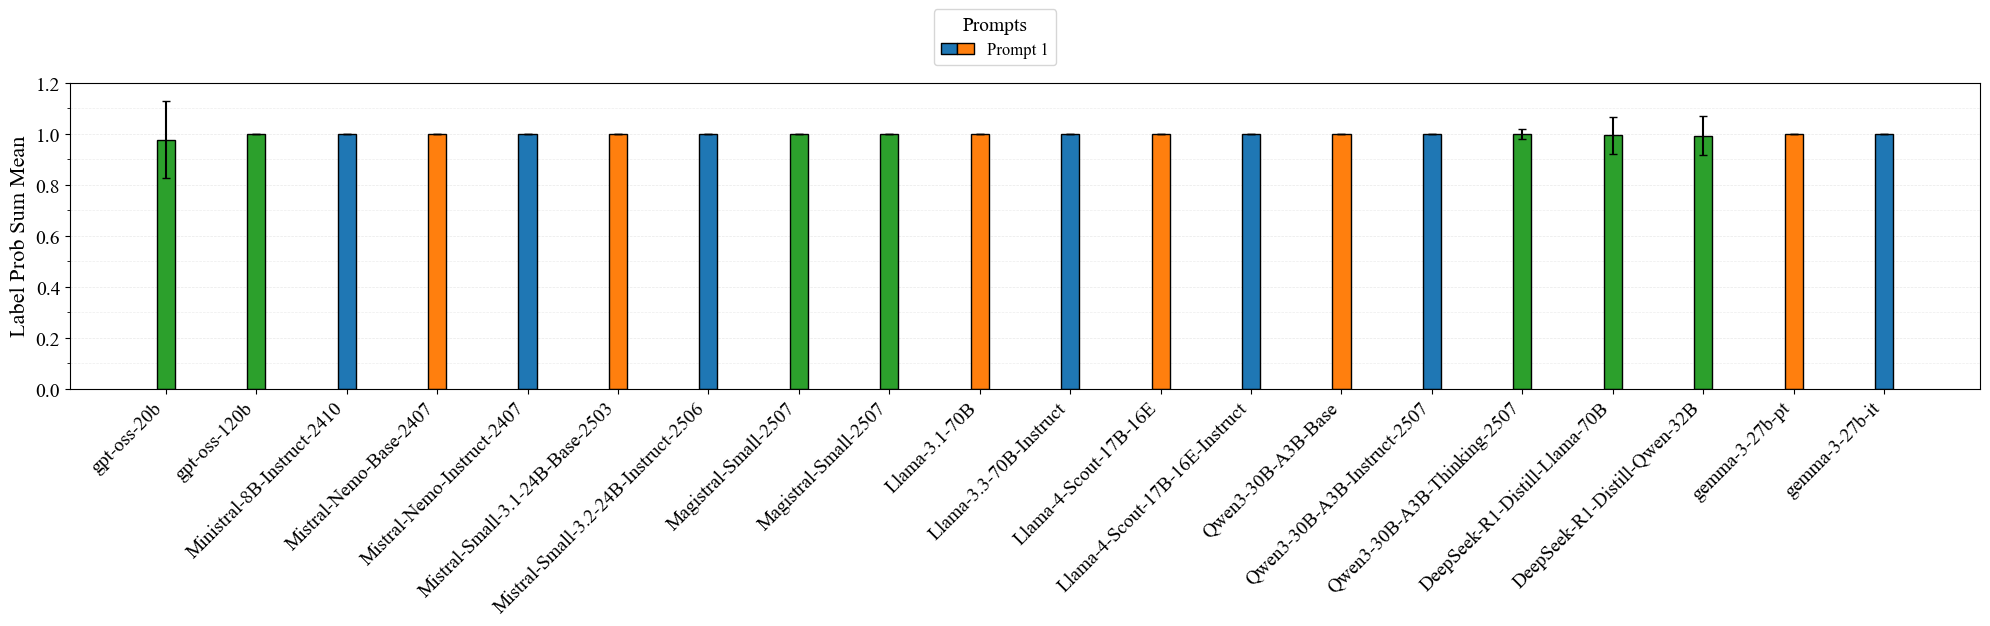

In [15]:
apply_matplotlib_defaults()
n_models  = len(model_ids)
n_prompts = len(prompt_designs)
bar_width = 0.2
x = np.arange(n_models)

fig, ax = plt.subplots(figsize=(20, 6))

for j, prompt in enumerate(prompt_designs):
    offset = (j - (n_prompts - 1) / 2) * bar_width
    for i, model in enumerate(models):
        mean, std = plot_data[model["id"]][prompt["basename"]]
        xpos = x[i] + offset
        c = prompt_colors[prompt["basename"]][model["type"]]
        ax.bar(xpos, mean, bar_width, yerr=std, capsize=3, color=c, edgecolor="black",
               label=prompt["basename"] if i == 0 else "")

ax.set_xticks(x)
ax.set_xticklabels(model_ids, rotation=45, ha="right", fontsize=14)
ax.set_ylabel("Label Prob Sum Mean", fontsize=16)
# y-axis: auto-scale to data with a small top margin; show minor gridlines every 0.1.
_max_mean = max(
    (plot_data[m_id][p["basename"]][0] for m_id in model_ids for p in prompt_designs),
    default=1.0,
)
_ylim = max(1.2, _max_mean * 1.15)
ax.set_ylim(0, _ylim)
_ytick_step = 0.2
_yticks = np.arange(0.0, _ylim + _ytick_step, _ytick_step)
ax.set_yticks(_yticks)
ax.set_yticklabels([f"{v:.1f}" for v in _yticks], fontsize=14)
ax.set_yticks(np.arange(0.0, _ylim + 0.1, 0.1), minor=True)
ax.set_axisbelow(True)
ax.grid(axis="y", color="lightgrey", linestyle="--")
ax.grid(axis="y", which="minor", color="lightgrey", linestyle="--", alpha=0.4)

legend_entries = [
    MulticolorPatch([prompt_colors[p["basename"]]["instruct"],
                     prompt_colors[p["basename"]]["base"]])
    for p in prompt_designs
]
legend_labels = [p["label"] for p in prompt_designs]
fig.legend(
    legend_entries, legend_labels,
    handler_map={MulticolorPatch: MulticolorPatchHandler()},
    loc="upper center", ncol=n_prompts, title="Prompts",
    bbox_to_anchor=(0.5, 1.05), fontsize=12, title_fontsize=14,
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(FIGURES_DIR / "label_prob_calibration.svg", bbox_inches="tight")
plt.savefig(FIGURES_DIR / "label_prob_calibration.png", bbox_inches="tight")
plt.show()

## LaTeX Tables

### Invalid Answers by Model and Prompt

Number of questions per model per prompt where no probability mass was assigned
to any answer choice, derived from `cal_data["invalid_answers"]`.

In [16]:
invalid_answers_counter = defaultdict(lambda: defaultdict(int))
for model, prompt, dataset in product(models, prompt_designs, all_datasets):
    m_id, pname, ds_id = model["id"], prompt["basename"], dataset["id"]
    entry = (cal_data[pname][ds_id][m_id] or {}).get("norm_chosen")
    if entry is not None:
        invalid_answers_counter[m_id][pname] += entry["invalid_answers"]

In [17]:
latex_invalid = (
    "\\begin{table}[h]\n\\centering\n"
    "\\begin{tabular}{l" + "c" * len(prompt_designs) + "}\n\\hline\n"
    + "Model & " + " & ".join(f"Prompt {p['idx']}" for p in prompt_designs) + " \\\\\n\\hline\n"
)
for model in models:
    row_data = [str(invalid_answers_counter[model["id"]].get(p["basename"], 0))
                for p in prompt_designs]
    latex_invalid += f"{model['id']} & " + " & ".join(row_data) + " \\\\\n"
latex_invalid += (
    "\\hline\n\\end{tabular}\n"
    "\\caption{Number of invalid answers given by models for different prompts across all datasets. "
    "Invalid answers do not assign any probability mass to the answer choice labels.}\n"
    "\\label{tab:invalid_answers}\n"
    "\\end{table}"
)

print(latex_invalid)
with open(TABLES_DIR / "invalid_answers.tex", "w", encoding="utf-8") as f:
    f.write(latex_invalid)

\begin{table}[h]
\centering
\begin{tabular}{lc}
\hline
Model & Prompt 1 \\
\hline
gpt-oss-20b & 395 \\
gpt-oss-120b & 0 \\
Ministral-8B-Instruct-2410 & 0 \\
Mistral-Nemo-Base-2407 & 0 \\
Mistral-Nemo-Instruct-2407 & 0 \\
Mistral-Small-3.1-24B-Base-2503 & 0 \\
Mistral-Small-3.2-24B-Instruct-2506 & 0 \\
Magistral-Small-2507 & 0 \\
Magistral-Small-2507 & 0 \\
Llama-3.1-70B & 0 \\
Llama-3.3-70B-Instruct & 0 \\
Llama-4-Scout-17B-16E & 0 \\
Llama-4-Scout-17B-16E-Instruct & 0 \\
Qwen3-30B-A3B-Base & 0 \\
Qwen3-30B-A3B-Instruct-2507 & 0 \\
Qwen3-30B-A3B-Thinking-2507 & 58 \\
DeepSeek-R1-Distill-Llama-70B & 152 \\
DeepSeek-R1-Distill-Qwen-32B & 248 \\
gemma-3-27b-pt & 0 \\
gemma-3-27b-it & 0 \\
\hline
\end{tabular}
\caption{Number of invalid answers given by models for different prompts across all datasets. Invalid answers do not assign any probability mass to the answer choice labels.}
\label{tab:invalid_answers}
\end{table}


### Label Probability Sum by Model Type and Prompt

Aggregate mean label-probability sum per model *type* (base, instruct, reasoning)
across all models of that type, then write a LaTeX table.

In [18]:
means_by_type = {
    key: {pname: [] for pname in prompt_basenames}
    for key in ["base", "instruct", "reasoning"]
}
for model, pname in product(models, prompt_basenames):
    mean, _ = plot_data[model["id"]][pname]
    means_by_type[model["type"]][pname].append(mean)

table_rows = {
    "Base Models": {},
    "Instruction Tuned Models": {},
    "Reasoning Models": {},
    "Average": {},
}
for pname in prompt_basenames:
    agg = {t: np.mean(means_by_type[t][pname]) if means_by_type[t][pname] else 0
           for t in ["base", "instruct", "reasoning"]}
    agg["avg"] = statistics.fmean(agg.values())
    table_rows["Base Models"][pname]              = f"{agg['base']:.4f}"
    table_rows["Instruction Tuned Models"][pname] = f"{agg['instruct']:.4f}"
    table_rows["Reasoning Models"][pname]         = f"{agg['reasoning']:.4f}"
    table_rows["Average"][pname]                  = f"{agg['avg']:.4f}"

latex_table = (
    "\n\\begin{table}[h]\n"
    "    \\centering\n"
    "    \\begin{tabular}{lcccc}\n"
    "        \\toprule\n"
    "        & Prompt 1 & Prompt 2 & Prompt 3 & Prompt 4 \\\\\n"
    "        \\midrule\n"
)
for row_name, values in table_rows.items():
    row_values = " & ".join(values[pname] for pname in prompt_basenames)
    latex_table += f"        {row_name} & {row_values} \\\\\n"
latex_table += (
    "        \\bottomrule\n"
    "    \\end{tabular}\n"
    "    \\caption{Mean over Sum of Label Probabilities per Question for Base and Instruction Tuned Models}\n"
    "    \\label{tab:labelprobsum}\n"
    "\\end{table}\n"
)

print(latex_table)
with open(TABLES_DIR / "prompt_design_label_prob_sum.tex", "w", encoding="utf-8") as f:
    f.write(latex_table)


\begin{table}[h]
    \centering
    \begin{tabular}{lcccc}
        \toprule
        & Prompt 1 & Prompt 2 & Prompt 3 & Prompt 4 \\
        \midrule
        Base Models & 1.0000 \\
        Instruction Tuned Models & 1.0000 \\
        Reasoning Models & 0.9950 \\
        Average & 0.9983 \\
        \bottomrule
    \end{tabular}
    \caption{Mean over Sum of Label Probabilities per Question for Base and Instruction Tuned Models}
    \label{tab:labelprobsum}
\end{table}



### ECE by Prompt Design

Per-dataset, per-model ECE values across all prompt designs, with mean and
max–min deviation columns.

In [19]:
prop = "ece"
table_data_ece = {}
dataset_stats = {}

for dataset in all_datasets:
    ds_id = dataset["id"]
    table_data_ece[ds_id] = {}
    deviations, means_list = [], []

    for model in models:
        m_id = model["id"]
        prop_list = []
        table_data_ece[ds_id][m_id] = {}

        for pname in prompt_basenames:
            try:
                value = cal_data[pname][ds_id][m_id]["norm_chosen"][prop]
            except (KeyError, TypeError):
                value = 0
            table_data_ece[ds_id][m_id][pname] = value
            prop_list.append(value)

        mean_value = np.mean(prop_list)
        deviation  = np.std(prop_list)
        table_data_ece[ds_id][m_id]["Mean"]      = mean_value
        table_data_ece[ds_id][m_id]["Deviation"] = deviation
        means_list.append(mean_value)
        deviations.append(deviation)

    dataset_stats[ds_id] = {
        "mean_deviation": np.mean(deviations),
        "std_deviation":  np.std(deviations),
        "mean_mean":      np.mean(means_list),
    }

latex_ece = (
    f"\n\\begin{{table}}[h]\n"
    f"    \\centering\n"
    f"    \\makebox[\\textwidth][c]{{%\n"
    f"    \\begin{{tabular}}{{l|lcccc|cc}}\n"
    f"        \\toprule\n"
    f"        Dataset & Model & Prompt 1 & Prompt 2 & Prompt 3 & Prompt 4 & Mean & max-min \\\\\n"
    f"        \\midrule\n"
)
for ds_id, models_ece in table_data_ece.items():
    first_row = True
    for model_id, prop_values in models_ece.items():
        row_values    = " & ".join(f"{prop_values[pname]:.4f}" for pname in prompt_basenames)
        mean_value    = f"{prop_values['Mean']:.4f}"
        prop_list     = [prop_values[pname] for pname in prompt_basenames]
        max_minus_min = f"{max(prop_list) - min(prop_list):.4f}"
        if first_row:
            latex_ece += (f"        \\multirow{{{len(models_ece)}}}{{*}}{{{ds_id}}} "
                          f"& {model_id} & {row_values} & {mean_value} & {max_minus_min} \\\\\n")
            first_row = False
        else:
            latex_ece += (f"        & {model_id} & {row_values} & {mean_value}"
                          f" & {max_minus_min} \\\\\n")
    latex_ece += "        \\midrule\n"

caption_parts = [
    f"{ds_id}: $\\mu_{{dev}}$={stats['mean_deviation']:.4f}, "
    f"$\\sigma_{{dev}}$={stats['std_deviation']:.4f}, "
    f"$\\mu_{{mean}}$={stats['mean_mean']:.4f}"
    for ds_id, stats in dataset_stats.items()
]
latex_ece += (
    "        \\bottomrule\n"
    "    \\end{tabular}\n"
    "    }\n"
    f"    \\caption{{ECE Across Prompts (using Probability of chosen Labels only) "
    f"with Mean and Deviation for each Dataset. Dataset-level statistics: "
    f"{' '.join(caption_parts)}. }}\n"
    "    \\label{tab:ece}\n"
    "\\end{table}\n"
)

print(latex_ece)
with open(TABLES_DIR / "prompt_design_ece.tex", "w", encoding="utf-8") as f:
    f.write(latex_ece)


\begin{table}[h]
    \centering
    \makebox[\textwidth][c]{%
    \begin{tabular}{l|lcccc|cc}
        \toprule
        Dataset & Model & Prompt 1 & Prompt 2 & Prompt 3 & Prompt 4 & Mean & max-min \\
        \midrule
        \multirow{19}{*}{MMLU} & gpt-oss-20b & 0.1691 & 0.1691 & 0.0000 \\
        & gpt-oss-120b & 0.1053 & 0.1053 & 0.0000 \\
        & Ministral-8B-Instruct-2410 & 0.0575 & 0.0575 & 0.0000 \\
        & Mistral-Nemo-Base-2407 & 0.0473 & 0.0473 & 0.0000 \\
        & Mistral-Nemo-Instruct-2407 & 0.1681 & 0.1681 & 0.0000 \\
        & Mistral-Small-3.1-24B-Base-2503 & 0.0940 & 0.0940 & 0.0000 \\
        & Mistral-Small-3.2-24B-Instruct-2506 & 0.1026 & 0.1026 & 0.0000 \\
        & Magistral-Small-2507 & 0.0613 & 0.0613 & 0.0000 \\
        & Llama-3.1-70B & 0.0660 & 0.0660 & 0.0000 \\
        & Llama-3.3-70B-Instruct & 0.1548 & 0.1548 & 0.0000 \\
        & Llama-4-Scout-17B-16E & 0.1093 & 0.1093 & 0.0000 \\
        & Llama-4-Scout-17B-16E-Instruct & 0.1749 & 0.1749 & 0.0000 \\

## Reasoning Chain Lengths

For reasoning models, visualise the distribution of answer-token lengths
(`amount_answer_tokens`) per dataset as grouped box plots.  Only values
≤ 10 240 tokens are shown (extreme outliers excluded).

  Skipping gpt-oss-20b/MMLU_Physics: Cache file data_struct_dec\data_prompt_1\MMLU_Physics\gpt-oss-20b\LabelProbExtractor.csv does not exist and create_okay is set to False.
  Skipping gpt-oss-120b/MMLU_Physics: Cache file data_struct_dec\data_prompt_1\MMLU_Physics\gpt-oss-120b\LabelProbExtractor.csv does not exist and create_okay is set to False.
  Skipping Magistral-Small-2507/MMLU_Physics: Cache file data_struct_dec\data_prompt_1\MMLU_Physics\Magistral-Small-2507\LabelProbExtractor.csv does not exist and create_okay is set to False.
  Skipping Magistral-Small-2507/MMLU_Physics: Cache file data_struct_dec\data_prompt_1\MMLU_Physics\Magistral-Small-2507\LabelProbExtractor.csv does not exist and create_okay is set to False.
  Skipping Qwen3-30B-A3B-Thinking-2507/MMLU_Physics: Cache file data_struct_dec\data_prompt_1\MMLU_Physics\Qwen3-30B-A3B-Thinking-2507\LabelProbExtractor.csv does not exist and create_okay is set to False.
  Skipping DeepSeek-R1-Distill-Llama-70B/MMLU_Physics: Cache

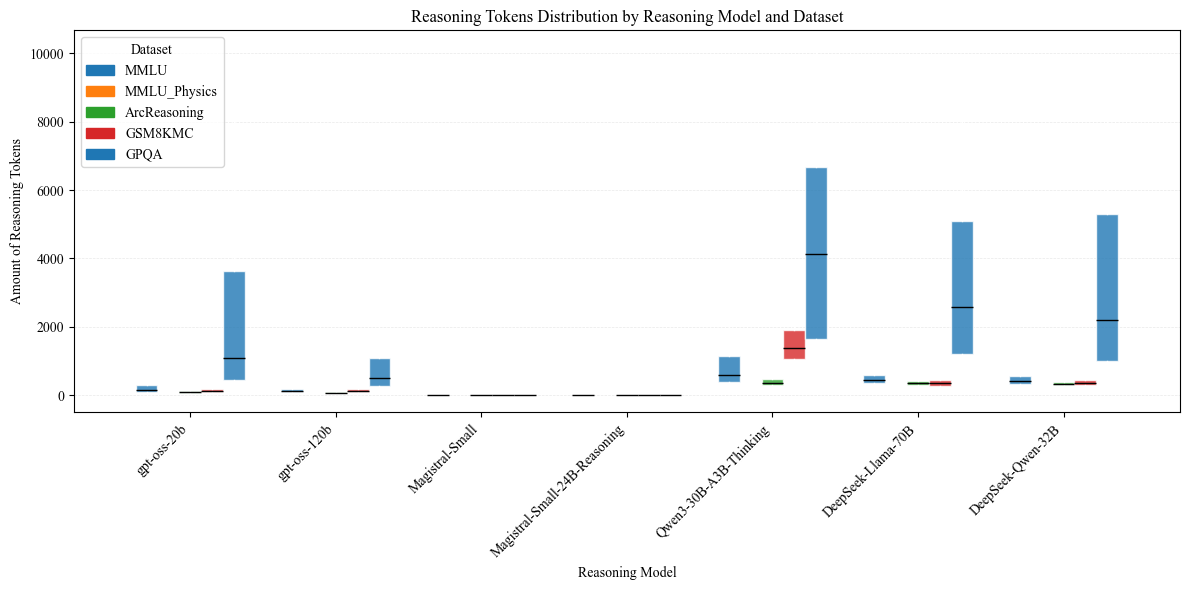

In [20]:
reasoning_models = [m for m in models if m["type"] == "reasoning"]

grouped_data = {d["id"]: [] for d in all_datasets}
model_labels = []
for model in reasoning_models:
    model_labels.append(model.get("shortname", model.get("basename", model["id"])))
    for dataset in all_datasets:
        try:
            result_path = prompt_designs[0]["path"] / dataset["id"] / model["id"]
            from async_graph_bench import CSVDataStore as _CSV
            lp_df = _CSV(result_path, "LabelProbExtractor").to_dataframe()
            series = lp_df["amount_answer_tokens"]
            data_values = series[series <= 10240].dropna().tolist()
            grouped_data[dataset["id"]].append(data_values)
        except Exception as e:
            print(f"  Skipping {model['id']}/{dataset['id']}: {e}")
            grouped_data[dataset["id"]].append([])

num_models   = len(reasoning_models)
num_datasets = len(all_datasets)
x_indexes    = np.arange(num_models)
box_width    = 0.15
ds_colors    = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

apply_matplotlib_defaults()
fig, ax = plt.subplots(figsize=(12, 6))
legend_handles = []
for i, dataset in enumerate(all_datasets):
    positions = x_indexes + (i - (num_datasets - 1) / 2) * box_width
    bp = ax.boxplot(
        grouped_data[dataset["id"]],
        positions=positions, widths=box_width,
        patch_artist=True, showfliers=False,
    )
    color = ds_colors[i % len(ds_colors)]
    for box in bp["boxes"]:
        box.set_facecolor(color)
        box.set_alpha(0.8)
    for median in bp["medians"]:
        median.set_color("black")
    legend_handles.append(mpatches.Patch(color=color, label=dataset["id"]))

ax.set_xticks(x_indexes)
ax.set_xticklabels(model_labels, rotation=45, ha="right")
ax.set_xlabel("Reasoning Model")
ax.set_ylabel("Amount of Reasoning Tokens")
ax.set_title("Reasoning Tokens Distribution by Reasoning Model and Dataset")
ax.legend(handles=legend_handles, title="Dataset")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
for ext in ["svg", "pdf"]:
    plt.savefig(FIGURES_DIR / f"label_probability_reasoning_lengths.{ext}", bbox_inches="tight")
plt.show()

In [21]:
pname = "data_prompt_1"
for dataset, model in product(all_datasets, models):
    ds_id, m_id = dataset["id"], model["id"]
    print(model['type'])
    cal_data['data_prompt_1'][ds_id][m_id]['norm_chosen']['normalized_entropy_100'] #float

reasoning
reasoning
instruct
base
instruct
base
instruct
reasoning
reasoning
base
instruct
base
instruct
base
instruct
reasoning
reasoning
reasoning
base
instruct
reasoning
reasoning
instruct
base
instruct
base
instruct
reasoning
reasoning
base
instruct
base
instruct
base
instruct
reasoning
reasoning
reasoning
base
instruct
reasoning
reasoning
instruct
base
instruct
base
instruct
reasoning
reasoning
base
instruct
base
instruct
base
instruct
reasoning
reasoning
reasoning
base
instruct
reasoning
reasoning
instruct
base
instruct
base
instruct
reasoning
reasoning
base
instruct
base
instruct
base
instruct
reasoning
reasoning
reasoning
base
instruct
reasoning
reasoning
instruct
base
instruct
base
instruct
reasoning
reasoning
base
instruct
base
instruct
base
instruct
reasoning
reasoning
reasoning
base
instruct


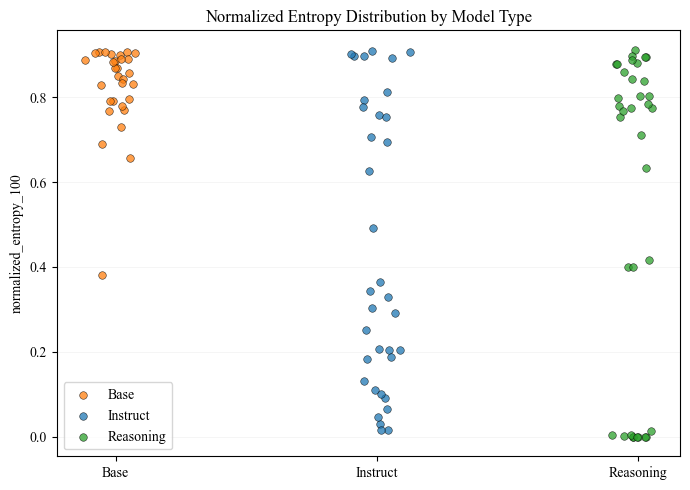

In [22]:
# Collect values grouped by model type
groups = {
    "base": [],
    "instruct": [],
    "reasoning": [],
}

pname = "data_prompt_1"

for dataset, model in product(all_datasets, models):
    ds_id = dataset["id"]
    m_id = model["id"]
    m_type = model["type"]

    try:
        val = cal_data[pname][ds_id][m_id]["norm_chosen"]["normalized_entropy_100"]

        if val is not None and np.isfinite(val):
            groups[m_type].append(val)

    except KeyError:
        continue

# Plot
fig, ax = plt.subplots(figsize=(7, 5))

order = ["base", "instruct", "reasoning"]
colors = {
    "base": "tab:orange",
    "instruct": "tab:blue",
    "reasoning": "tab:green",
}

# Simple swarm positioning
rng = np.random.default_rng(42)

for i, group in enumerate(order):
    y = np.array(groups[group])

    # horizontal jitter
    x = rng.normal(loc=i, scale=0.06, size=len(y))

    ax.scatter(
        x,
        y,
        s=30,
        alpha=0.75,
        color=colors[group],
        edgecolor="black",
        linewidth=0.4,
        label=group.capitalize(),
    )

# Styling
ax.set_xticks(range(len(order)))
ax.set_xticklabels([g.capitalize() for g in order])
ax.set_ylabel("normalized_entropy_100")
ax.set_title("Normalized Entropy Distribution by Model Type")

ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

# Avoid duplicate legend entries
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys())

plt.tight_layout()
plt.show()

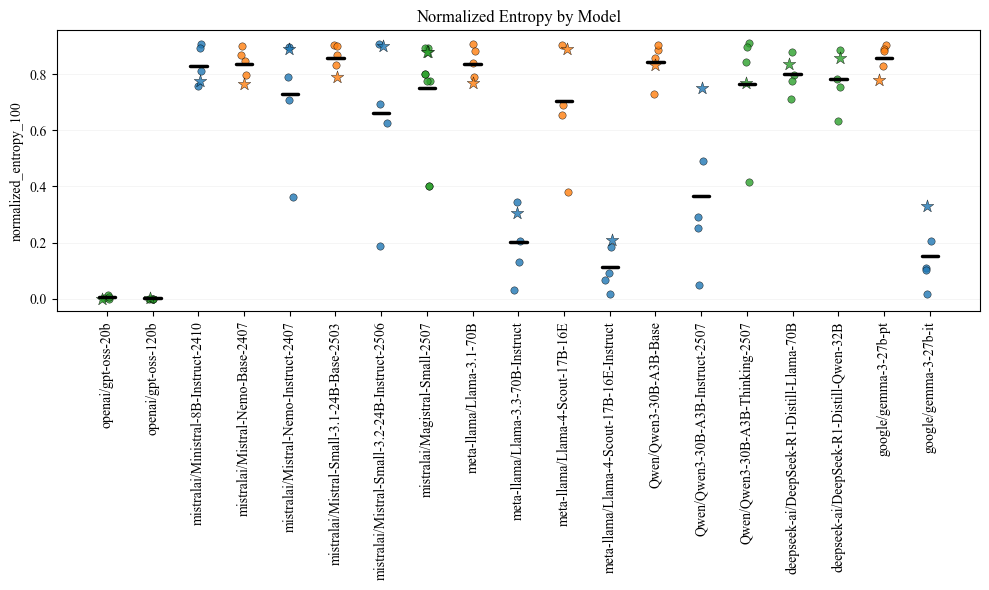

In [23]:
# Collect values grouped by model
model_values = defaultdict(list)
model_types = {}

pname = "data_prompt_1"

for dataset, model in product(all_datasets, models):
    ds_id = dataset["id"]
    m_id = model["id"]

    model_name = model.get("name", m_id)
    model_type = model["type"]

    try:
        val = cal_data[pname][ds_id][m_id]["norm_chosen"]["normalized_entropy_100"]

        if val is not None and np.isfinite(val):
            model_values[model_name].append((ds_id, val))
            model_types[model_name] = model_type

    except KeyError:
        continue

# Sort models by type, then name
type_order = {"base": 0, "instruct": 1, "reasoning": 2}

sorted_models = list(model_values.keys())
# sorted(
#     model_values.keys(),
#     key=lambda m: (type_order.get(model_types[m], 999), m.lower())
# )

# Colors
colors = {
    "base": "tab:orange",
    "instruct": "tab:blue",
    "reasoning": "tab:green",
}

# Datasets that should use star markers
star_datasets = {"GPQA", "SciBench"}

# Plot
fig, ax = plt.subplots(figsize=(max(10, len(sorted_models) * 0.45), 6))

rng = np.random.default_rng(42)

for i, model_name in enumerate(sorted_models):
    entries = model_values[model_name]

    ys_for_mean = []

    for ds_id, val in entries:
        ys_for_mean.append(val)

        x = rng.normal(loc=i, scale=0.06)

        color = colors[model_types[model_name]]

        # star marker for GPQA / SciBench
        marker = "*" if ds_id in star_datasets else "o"
        size = 90 if marker == "*" else 28

        ax.scatter(
            x,
            val,
            s=size,
            alpha=0.8,
            color=color,
            marker=marker,
            edgecolor="black",
            linewidth=0.35,
        )

    # mean line
    mean_y = np.mean(ys_for_mean)

    ax.plot(
        [i - 0.18, i + 0.18],
        [mean_y, mean_y],
        linewidth=2.5,
        color="black",
        solid_capstyle="round",
    )

# Styling
ax.set_xticks(range(len(sorted_models)))
ax.set_xticklabels(sorted_models, rotation=90)

ax.set_ylabel("normalized_entropy_100")
ax.set_title("Normalized Entropy by Model")

ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

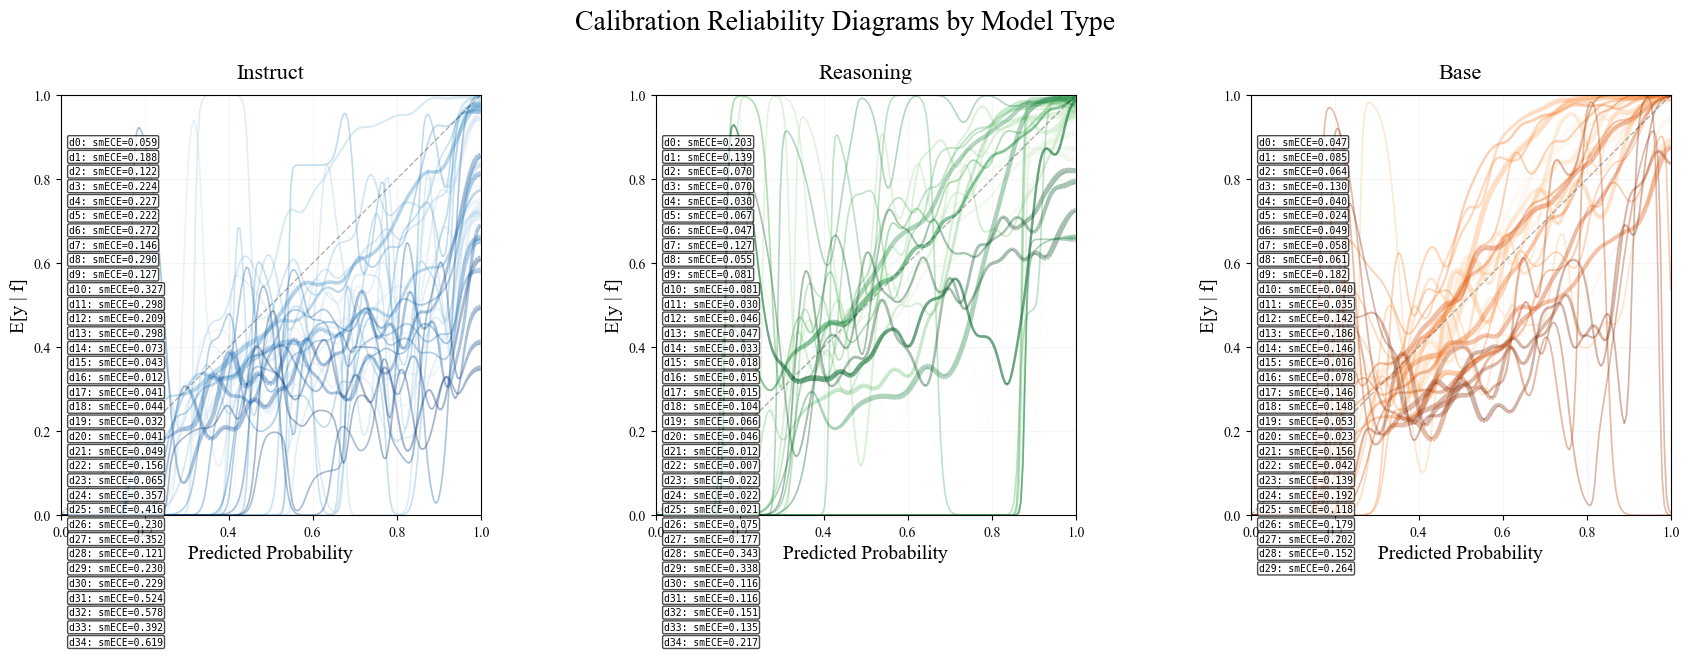

In [24]:
# Calibrated reliability diagrams grouped by model type.
# For each model type (base/instruct/reasoning) collect all relplot_diagram dicts
# across every (dataset, model) pair and overlay them on a single axes.
from util.multi_relplot import plot_multi_rel_diagram

type_diagrams = {t: [] for t in ["instruct", "reasoning", "base"]}

pname = "data_prompt_1"

for dataset, model in product(all_datasets, models):
    ds_id, m_id, m_type = dataset["id"], model["id"], model["type"]

    entry = (cal_data.get(pname, {}).get(ds_id, {}).get(m_id) or {})
    nc = entry.get("norm_chosen")
    if nc is None or not isinstance(nc, dict):
        continue
    diagram = nc.get("relplot_diagram")
    if diagram is not None and m_type in type_diagrams:
        type_diagrams[m_type].append(diagram)

color_map = {"base": "tab:orange", "instruct": "tab:blue", "reasoning": "tab:green"}

cmap_map = {"base": "Oranges", "instruct": "Blues", "reasoning": "Greens"}

fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                         subplot_kw={"aspect": "equal"})
for ax, (m_type, diagrams) in zip(axes, type_diagrams.items()):
    if len(diagrams) == 0:
        ax.text(0.5, 0.5, "no data", ha="center", va="center",
                transform=ax.transAxes, fontsize=14, color="grey")
        ax.set_title(m_type.capitalize(), fontsize=16)
        continue

    fig_tmp, _ = plot_multi_rel_diagram(
        diagrams, ax=ax, fig=fig, use_default_style=False,
        color_cmap=cmap_map[m_type],
        line_alpha=0.35, plot_diagonal=True, plot_ticks=False,
        show_legend=False, ece_key='ce',
    )
    ax.set_title(m_type.capitalize(), fontsize=16, pad=12)
    ax.set_xlabel("Predicted Probability", fontsize=14)
    ax.set_ylabel("E[y | f]", fontsize=14)

fig.suptitle("Calibration Reliability Diagrams by Model Type", fontsize=20, y=1.04)
fig.tight_layout()
plt.savefig(FIGURES_DIR / "calibration_by_model_type.svg", bbox_inches="tight")
plt.show()